In [2]:
import numpy as np
import matplotlib.pyplot as plt
from gen_sample import gen_sample
from SSDpy import signal as sp
import SSDpy as ssd

import pickle
import time


# Set default color order
cmp = plt.rcParams['axes.prop_cycle'].by_key()['color']

# Generate signals
X = []
S = []
for i in range(0, 4):
    x, t, dt = gen_sample(i)  # Replace genSample with gen_sample
    X.append(x.flatten())
    s, f, _ = sp.vpsd(x, 4096, dt)  # Replace VincePSD with vince_psd
    s[0] = s[1]
    S.append(s.flatten())

X = np.array(X).T
S = np.array(S).T


ModuleNotFoundError: No module named 'bayes'

/var/folders/1k/02kwr65j3qq3t038h5fhrm180000gn/T/ipykernel_98714/2848216941.py:35: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  plt.tight_layout()  # Adjust layout to avoid overlap


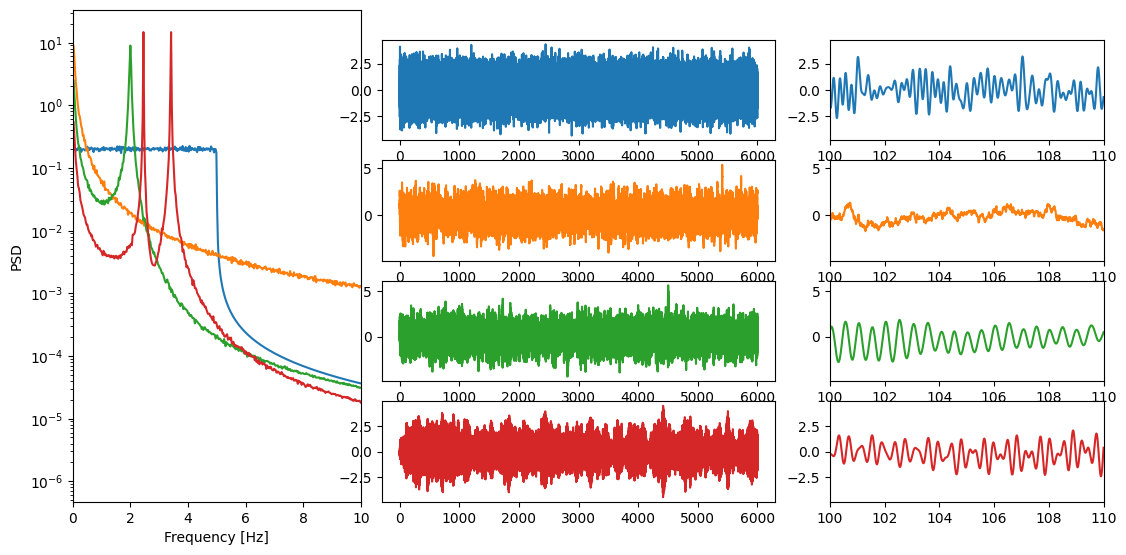

In [4]:
# Plot the data
fig, hp = plt.subplots(4, 3, figsize=(12, 6))  # Create a grid of 4x3 subplots
hp = hp.flatten()  # Flatten the 2D array to a 1D list of subplots
# Delete subplots in positions 4, 7, and 10
for i in [3, 6, 9]:
    fig.delaxes(hp[i])  # Remove subplot at index `i`
    hp[i] = None  # Mark as deleted for clarity
# Adjust the position of subplots in columns 2 and 3
for i in [1, 4, 7, 10]:  # Corresponding subplot indices for columns 2
    pos = hp[i].get_position()
    hp[i].set_position([pos.x0 - 0.1, pos.y0, pos.width + 0.1, pos.height])
# Adjust position of the first subplot
hp[0].set_position([0.041, 0.11, 0.24, 0.82])

# Plot the data
for i in range(4):
    # Plot PSD on the first subplot
    ax1 = hp[0]
    ax1.semilogy(f, S[:, i], color=cmp[i])
    ax1.set_xlim([0, 10])
    ax1.set_xlabel("Frequency [Hz]")
    ax1.set_ylabel("PSD")

    # Plot time series on the middle column
    ax2 = hp[3 * i + 1]
    if ax2:
        ax2.plot(t, X[0:-1, i], color=cmp[i])

    # Plot zoomed time series on the last column
    ax3 = hp[3 * i + 2]
    if ax3:
        ax3.plot(t, X[0:-1, i], color=cmp[i])
        ax3.set_xlim([100, 110])

plt.tight_layout()  # Adjust layout to avoid overlap
plt.show()

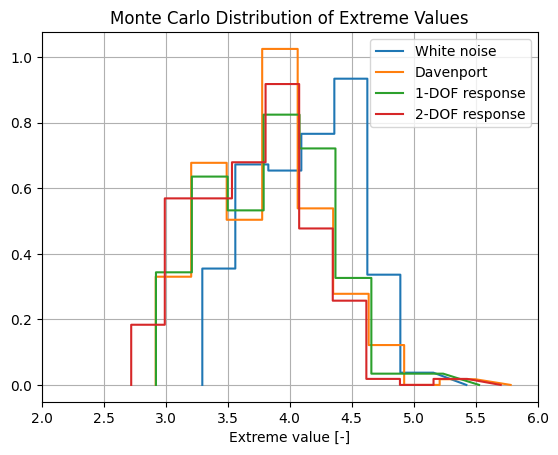

In [7]:
# Initialize or load data
dothis = False  # Perform the Monte Carlo simulation (could be long)
nbRuns = 1000  # Number of Monte Carlo runs

# try to load the data, if available from previous run. If yes, we'll append new data to it
try:
    with open("MC_distrib.pkl", "rb") as f:
        extreme = pickle.load(f)
except FileNotFoundError:
    extreme = []

if dothis:  # Perform the Monte Carlo simulation (could be long)
    start_time = time.time()
    k_start = len(extreme)
    extreme = np.array(extreme) if len(extreme) > 0 else np.empty((0, 4))  # Ensure `extreme` is a NumPy array

    for k in range(k_start, nbRuns):
        new_extreme = []
        for i in range(4):
            x, t, dt = gen_sample(i)
            new_extreme.append(max(x))
        extreme = np.vstack((extreme, new_extreme))  # Append new data row-wise

        # Save every 100 iterations
        if k % 100 == 0:
            with open("MC_distrib.pkl", "wb") as f:
                pickle.dump(extreme, f)
            print("Saved")
            plt.clf()  # Clear figure
            for i in range(4):
                nn, xx = sp.histv(extreme[:, i])
                plt.plot(xx, nn, color=cmp[i])
            plt.xlim([2, 6])
            plt.xlabel("Extreme value [-]")
            plt.pause(0.01)  # Update the plot dynamically

        elapsed_time = time.time() - start_time
        print(f"Entry {k}, time {elapsed_time:.2f} seconds")
        start_time = time.time()  # Reset the timer

    # Save the final data
    with open("MC_distrib.pkl", "wb") as f:
        pickle.dump(extreme, f)
else:
    # Load previously saved data
    with open("MC_distrib.pkl", "rb") as f:
        extreme = pickle.load(f)

# Final plot of the distributions
plt.figure()
for i in range(4):
    nn, xx = sp.histv(extreme[:, i])
    plt.plot(xx, nn, color=cmp[i])
plt.xlim([2, 6])
plt.xlabel("Extreme value [-]")
plt.legend(["White noise", "Davenport", "1-DOF response", "2-DOF response"], loc="upper right")
plt.title("Monte Carlo Distribution of Extreme Values")
plt.grid(True)
plt.show()


In [16]:
%load_ext autoreload
%autoreload 2

import SSDpy as ssd
print(dir(ssd))
#ssd.histv(extreme[:, 0], bins=50, color=cmp[0], label="White noise")

['__builtins__', '__cached__', '__doc__', '__file__', '__loader__', '__name__', '__package__', '__path__', '__spec__', 'dyn', 'signal']
